# Fine-tuning clasificador de especies de ECHO

## 1. Setup

In [2]:
!pip -q install scikit-learn tqdm matplotlib pandas

import os
import json
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split

!pip -q install PytorchWildlife openpyxl

import re
import unicodedata
import pandas as pd
import openpyxl

from PIL import Image, ImageOps
from PytorchWildlife.models import detection as pw_detection


print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA disponible:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.4/953.4 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 15.6 MB/s eta 0:00:00

## 2. Configuración general

In [13]:
USE_GOOGLE_DRIVE = True
# Paths de carpeta de imagenes de entrenamiento y metadata
DRIVE_ZIP_PATH = "/content/drive/MyDrive/ECHO/Metadata/preprocessed_images.zip"
DRIVE_METADATA_PATH = "/content/drive/MyDrive/ECHO/Metadata/detections_metadata.json"

# carpeta temporal
WORK_DIR = Path("/content/saviia_species_training")
EXTRACT_DIR = WORK_DIR / "preprocessed_images"
OUTPUT_DIR = WORK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# configuraciones de entrenamiento del modelo
SEED = 42
IMG_SIZE = 224
VAL_SIZE = 0.20
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS_HEAD = 5          # Etapa 1 - entrenar solo el clasificador final
EPOCHS_FINETUNE = 10     # Etapa 2 - fine-tuning de layer4 + clasificador
EPOCHS_FINETUNE_ALL = 3
EXTRA_FINETUNE_EPOCHS = 2
LR_FINETUNE_ALL = 1e-6
LR_HEAD = 3e-4
LR_FINETUNE = 3e-5
LR_RESUME = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
USE_WEIGHTED_SAMPLER = False

# archivos finales del model (pesos)
BEST_MODEL_PATH = OUTPUT_DIR / "resnet50_species_best.pt"
LAST_MODEL_PATH = OUTPUT_DIR / "resnet50_species_last.pt"
HISTORY_PATH = OUTPUT_DIR / "training_history.csv"
CLASS_MAPPING_PATH = OUTPUT_DIR / "class_mapping.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

## 3. Montar Drive y descomprimir dataset

In [5]:
# extraccion zip de imagenes de entrenamiento
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

zip_path = Path(DRIVE_ZIP_PATH)
metadata_path = Path(DRIVE_METADATA_PATH)

if not zip_path.exists():
    raise FileNotFoundError(f"No se encontró el ZIP en: {zip_path}")

print("ZIP encontrado:", zip_path)
print("Metadata encontrado:", metadata_path.exists(), metadata_path)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
if not any(EXTRACT_DIR.iterdir()):
    print("Descomprimiendo dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Dataset descomprimido en:", EXTRACT_DIR)
else:
    print("Dataset ya estaba descomprimido en:", EXTRACT_DIR)

Mounted at /content/drive
ZIP encontrado: /content/drive/MyDrive/ECHO/Metadata/preprocessed_images.zip
Metadata encontrado: True /content/drive/MyDrive/ECHO/Metadata/detections_metadata.json
Descomprimiendo dataset...
Dataset descomprimido en: /content/saviia_species_training/preprocessed_images


In [7]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def contains_images(path: Path) -> bool:
    return any(p.is_file() and p.suffix.lower() in VALID_EXTENSIONS for p in path.iterdir())

def is_imagefolder_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    return len(class_dirs) > 0 and any(contains_images(d) for d in class_dirs)

def find_imagefolder_root(base_dir: Path) -> Path:
    """Busca una carpeta con estructura clase/imagenes para usar ImageFolder."""
    if is_imagefolder_root(base_dir):
        return base_dir

    for p in base_dir.rglob("*"):
        if p.is_dir() and is_imagefolder_root(p):
            return p

    raise RuntimeError(
        "No se encontró una estructura compatible con ImageFolder. "
        "Se espera algo como: root/0/img1.jpg, root/1/img2.jpg, ..."
    )
# carpeta de cada clase
DATA_ROOT = find_imagefolder_root(EXTRACT_DIR)
print("DATA_ROOT detectado:", DATA_ROOT)
print("Carpetas de clase detectadas:", sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])[:30])

# eliminar .ipynb_checkpoints
for p in EXTRACT_DIR.rglob(".*"):
    if p.is_dir():
        p.rmdir()

DATA_ROOT detectado: /content/saviia_species_training/preprocessed_images/content/tmp
Carpetas de clase detectadas: ['.ipynb_checkpoints', '0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']


## 4. Cargar metadata y mapear

In [8]:
def load_class_id_to_name(metadata_path: Path) -> dict:
    if not metadata_path.exists():
        print("No se encontró metadata. Se usarán los IDs de carpeta como nombres de clase.")
        return {}

    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    class_id_to_name = {}

    # Estructura esperada:
    # {
    #   "0": {
    #     "image.png": {"class_id": "0", "class_name": "Hued hued", ...}
    #   },
    #   ...
    # }
    for top_key, value in metadata.items():
        if isinstance(value, dict):
            for _, item in value.items():
                if isinstance(item, dict):
                    class_id = str(item.get("class_id", top_key))
                    class_name = item.get("class_name")
                    if class_name:
                        class_id_to_name[class_id] = class_name

    return class_id_to_name

class_id_to_name = load_class_id_to_name(metadata_path)
print("Clases encontradas en metadata:", len(class_id_to_name))
class_id_to_name

Clases encontradas en metadata: 21


{'0': 'Hued hued',
 '1': 'Pudu',
 '2': 'Puma',
 '3': 'Guina',
 '4': 'Chucao',
 '5': 'Zorzal',
 '6': 'Caballo',
 '7': 'Chingue',
 '8': 'Guanaco',
 '9': 'Huemul',
 '10': 'Liebre europea',
 '11': 'Oveja',
 '12': 'Perro domestico',
 '13': 'Vaca',
 '14': 'Zorro culpeo',
 '15': 'Vison americano',
 '16': 'Quique',
 '17': 'Jabali',
 '18': 'Zorro chilla',
 '19': 'Conejo europeo',
 '20': 'Gato domestico'}

## 5. Datasets y split train-validation


In [9]:
weights = ResNet50_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

# ajustamos las imagenes para entrenamiento con resnet50

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


# transformaciones dataset de train y val
train_dataset_full = datasets.ImageFolder(root=DATA_ROOT, transform=base_transform)
val_dataset_full = datasets.ImageFolder(root=DATA_ROOT, transform=base_transform)

num_classes = len(train_dataset_full.classes)
print("Número de clases:", num_classes)
print("Número total de imágenes:", len(train_dataset_full))
print("class_to_idx:", train_dataset_full.class_to_idx)

Número de clases: 21
Número total de imágenes: 5721
class_to_idx: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '3': 14, '4': 15, '5': 16, '6': 17, '7': 18, '8': 19, '9': 20}


In [10]:
# mapeos internos del modelo
class_to_idx = train_dataset_full.class_to_idx
idx_to_class_id = {idx: class_id for class_id, idx in class_to_idx.items()}
idx_to_class_name = {
    idx: class_id_to_name.get(class_id, class_id)
    for idx, class_id in idx_to_class_id.items()
}

# conteo de imágenes por clase
all_targets = np.array([target for _, target in train_dataset_full.samples])
class_counts = Counter(all_targets)

class_table = pd.DataFrame([
    {
        "model_idx": idx,
        "class_id": idx_to_class_id[idx],
        "class_name": idx_to_class_name[idx],
        "n_images": class_counts[idx],
    }
    for idx in sorted(idx_to_class_id.keys())
]).sort_values("model_idx")

class_table

,model_idx,class_id,class_name,n_images
0,0,0,Hued hued,458
1,1,1,Pudu,463
2,2,10,Liebre europea,202
3,3,11,Oveja,196
4,4,12,Perro domestico,199
5,5,13,Vaca,191
6,6,14,Zorro culpeo,201
7,7,15,Vison americano,193
8,8,16,Quique,177
9,9,17,Jabali,205


In [11]:
indices = np.arange(len(train_dataset_full))
targets = np.array([target for _, target in train_dataset_full.samples])
# creacion de datasets
try:
    train_idx, val_idx = train_test_split(
        indices,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=targets,
    )
except ValueError as e:
    print("No se pudo hacer split estratificado. Se usará split aleatorio.")
    print("Detalle:", e)
    train_idx, val_idx = train_test_split(
        indices,
        test_size=VAL_SIZE,
        random_state=SEED,
        shuffle=True,
    )

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("% split train-val: ", VAL_SIZE)

Train: 4576
Validation: 1145
% split train-val:  0.2


In [16]:
# Balance de clases

def build_train_sampler(targets: np.ndarray, train_idx: np.ndarray):
    """ Balance de clases durante el entrenamiento """
    train_targets = targets[train_idx]
    counts = np.bincount(train_targets, minlength=num_classes)
    counts = np.maximum(counts, 1)
    class_weights = 1.0 / counts
    sample_weights = class_weights[train_targets]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
print("Usar balance de clases: ", USE_WEIGHTED_SAMPLER)
if USE_WEIGHTED_SAMPLER:
    train_sampler = build_train_sampler(targets, train_idx)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        num_workers=0,
        pin_memory=False,
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("Batches train:", len(train_loader))
print("Batches validation:", len(val_loader))

Usar balance de clases:  False
Batches train: 143
Batches validation: 36


## 6. Modelo ResNet50

Entrenamiento en dos etapas:

1. **Head training:** se congela la base de ResNet50 y se entrena solo la capa final.
2. **Fine-tuning:** se descongela `layer4` y la capa final para ajustar representaciones al dataset de especies.

In [17]:
def build_resnet50(num_classes: int) -> nn.Module:
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features
    # ultima capa
    model.fc = nn.Linear(in_features, num_classes)
    return model

model = build_resnet50(num_classes=num_classes).to(DEVICE)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 122MB/s]


Linear(in_features=2048, out_features=21, bias=True)


In [18]:
def set_trainable_layers(model: nn.Module, stage: str):
    """ Control capas que se entrenan en cada etapa."""
    if stage == "head":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True

    elif stage == "finetune_layer4":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    elif stage == "all":
        for param in model.parameters():
            param.requires_grad = True

    else:
        raise ValueError(f"Stage no soportado: {stage}")


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """
    Entrenamiento del modelo y actualizacion de sus pesos
    """
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    progress = tqdm(loader, desc="train", leave=False)
    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        amp_device = "cuda" if device.type == "cuda" else "cpu"
        with autocast(device_type=amp_device, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        preds = logits.argmax(dim=1)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        running_total += batch_size

        progress.set_postfix({
            "loss": running_loss / max(running_total, 1),
            "acc": running_correct / max(running_total, 1),
        })

    return running_loss / running_total, running_correct / running_total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluacion del modelo con el conjunto de validacion
    """
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    progress = tqdm(loader, desc="val", leave=False)
    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        amp_device = "cuda" if device.type == "cuda" else "cpu"
        with autocast(device_type=amp_device, enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        batch_size = labels.size(0)
        preds = logits.argmax(dim=1)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        running_total += batch_size

        progress.set_postfix({
            "loss": running_loss / max(running_total, 1),
            "acc": running_correct / max(running_total, 1),
        })

    return running_loss / running_total, running_correct / running_total

In [20]:
def save_checkpoint(path: Path, model: nn.Module, history: list, best_val_acc: float, epoch_info: dict):
    checkpoint = {
        "model_name": "resnet50",
        "num_classes": num_classes,
        "image_size": IMG_SIZE,
        "model_state_dict": model.state_dict(),
        "class_to_idx": class_to_idx,
        "idx_to_class_id": idx_to_class_id,
        "idx_to_class_name": idx_to_class_name,
        "class_id_to_name": class_id_to_name,
        "best_val_acc": best_val_acc,
        "history": history,
        "epoch_info": epoch_info,
    }
    torch.save(checkpoint, path)


def run_training_stage(model, stage_name: str, epochs: int, lr: float, history: list, best_val_acc: float):
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))

    amp_device = "cuda" if DEVICE.type == "cuda" else "cpu"
    scaler = GradScaler(amp_device, enabled=(DEVICE.type == "cuda"))

    print(f"\n=== Etapa: {stage_name} ===")
    print("Parámetros entrenables:", count_trainable_params(model))

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        row = {
            "stage": stage_name,
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
        history.append(row)

        print(
            f"[{stage_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(
                BEST_MODEL_PATH,
                model,
                history,
                best_val_acc,
                {"stage": stage_name, "epoch": epoch},
            )
            print(f"Nuevo mejor modelo guardado en: {BEST_MODEL_PATH} | val_acc={best_val_acc:.4f}")

        pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

    save_checkpoint(
        LAST_MODEL_PATH,
        model,
        history,
        best_val_acc,
        {"stage": stage_name, "epoch": epochs},
    )
    return history, best_val_acc

## 8. Entrenamiento

- `resnet50_species_best.pt`: mejor checkpoint según accuracy de validación.
- `resnet50_species_last.pt`: último checkpoint.
- `training_history.csv`: historial de métricas.
- `class_mapping.json`: mapeo entre índice del modelo, class_id y nombre de especie.

Usamos transfer learning con ResNet50 preentrenado, reemplazando su capa final por un clasificador adaptado a las 21 especies del dataset.

Inicialmente congelamos todas las capas de la red y entrenamos solo la capa final (fc).

Luego aplicamos fine-tuning parcial descongelando layer4 (ultimo bloque convolucional de ResNet50) junto con la capa final, donde entrenamos con las características mas específicas y de alto nivel

Es decir, tenemos 2 estapas
- Etapa 1: aprendemos a clasificar las especies usando ResNet50 congelada (head)

- Etapa 2: layer4 + head: ajustamos las features finales de ResNet50 a las imagenes

In [21]:
# Configuraciones checkpoint
RESUME_FROM_CHECKPOINT = True
CHECKPOINT_TO_LOAD = BEST_MODEL_PATH
# Configuraciones epocas de finetune
EXTRA_FINETUNE_EPOCHS = 2
LR_RESUME = 1e-5

if RESUME_FROM_CHECKPOINT and CHECKPOINT_TO_LOAD.exists():
    print(f"Cargando checkpoint desde: {CHECKPOINT_TO_LOAD}")

    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    history = checkpoint.get("history", [])
    best_val_acc = checkpoint.get("best_val_acc", 0.0)

    print("Checkpoint cargado correctamente.")
    print("Best val_acc anterior:", best_val_acc)
    print("Última info guardada:", checkpoint.get("epoch_info", {}))

    # por mientras entrenamos solo el ultimo bloque convolucional de resnet
    # layer4 + fc
    set_trainable_layers(model, stage="finetune_layer4")

    history, best_val_acc = run_training_stage(
        model=model,
        stage_name="finetune_layer4_resume_low_lr",
        epochs=EXTRA_FINETUNE_EPOCHS,
        lr=LR_RESUME,
        history=history,
        best_val_acc=best_val_acc,
    )

else:
    print("No se cargó checkpoint. Entrenando desde cero.")

    history = []
    best_val_acc = 0.0
    # entrenamos ultima capa del modelo
    set_trainable_layers(model, stage="head")
    history, best_val_acc = run_training_stage(
        model=model,
        stage_name="head",
        epochs=EPOCHS_HEAD,
        lr=LR_HEAD,
        history=history,
        best_val_acc=best_val_acc,
    )
    # entrenamos el ultimo bloque convlucional de resnet50
    set_trainable_layers(model, stage="finetune_layer4")
    history, best_val_acc = run_training_stage(
        model=model,
        stage_name="finetune_layer4",
        epochs=EPOCHS_FINETUNE,
        lr=LR_FINETUNE,
        history=history,
        best_val_acc=best_val_acc,
    )

print("\nEntrenamiento completado.")
print("Mejor val_acc:", best_val_acc)
print("Mejor checkpoint:", BEST_MODEL_PATH)
print("Último checkpoint:", LAST_MODEL_PATH)
print("Historial:", HISTORY_PATH)
print("Mapeo de clases:", CLASS_MAPPING_PATH)

No se cargó checkpoint. Entrenando desde cero.

=== Etapa: head ===
Parámetros entrenables: 43029


train:   0%|          | 0/143 [00:00<?, ?it/s]

val:   0%|          | 0/36 [00:00<?, ?it/s]

[head] Epoch 01/5 | train_loss=2.5853 train_acc=0.2738 | val_loss=2.2426 val_acc=0.5328
Nuevo mejor modelo guardado en: /content/saviia_species_training/outputs/resnet50_species_best.pt | val_acc=0.5328


train:   0%|          | 0/143 [00:00<?, ?it/s]

...

val:   0%|          | 0/36 [00:00<?, ?it/s]

[finetune_layer4] Epoch 09/10 | train_loss=0.5191 train_acc=0.9692 | val_loss=0.7986 val_acc=0.8550
Nuevo mejor modelo guardado en: /content/saviia_species_training/outputs/resnet50_species_best.pt | val_acc=0.8550


train:   0%|          | 0/143 [00:00<?, ?it/s]

val:   0%|          | 0/36 [00:00<?, ?it/s]

[finetune_layer4] Epoch 10/10 | train_loss=0.5161 train_acc=0.9714 | val_loss=0.8031 val_acc=0.8507

Entrenamiento completado.
Mejor val_acc: 0.8550218340611354
Mejor checkpoint: /content/saviia_species_training/outputs/resnet50_species_best.pt
Último checkpoint: /content/saviia_species_training/outputs/resnet50_species_last.pt
Historial: /content/saviia_species_training/outputs/training_history.csv
Mapeo de clases: /content/saviia_species_training/outputs/class_mapping.json


## 9. Training and validation loss


In [24]:
history_df = pd.read_csv(HISTORY_PATH)
display(history_df)

,stage,epoch,lr,train_loss,train_acc,val_loss,val_acc
0,head,1,2.713525e-04,2.585331,0.273820,2.242583,0.532751
1,head,2,1.963525e-04,2.003683,0.617133,1.885073,0.627948
2,head,3,1.036475e-04,1.738277,0.680507,1.709970,0.668996
3,head,4,2.864745e-05,1.602081,0.712631,1.637216,0.676856
4,head,5,0.000000e+00,1.551111,0.733610,1.610586,0.683843
5,finetune_layer4,1,2.926585e-05,1.220399,0.745192,1.126907,0.753712
6,finetune_layer4,2,2.713525e-05,0.922460,0.828890,0.996981,0.786900
7,finetune_layer4,3,2.381678e-05,0.775822,0.883741,0.919482,0.816594
8,finetune_layer4,4,1.963525e-05,0.685470,0.916958,0.873192,0.827074
9,finetune_layer4,5,1.500000e-05,0.611186,0.940778,0.842097,0.838428


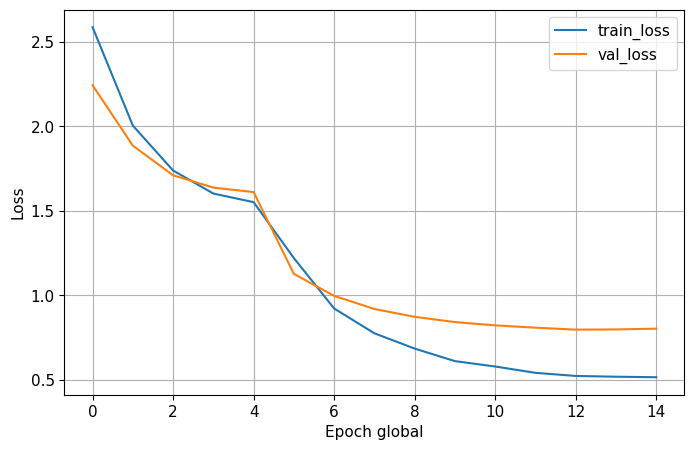

In [28]:
%matplotlib inline
plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch global")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

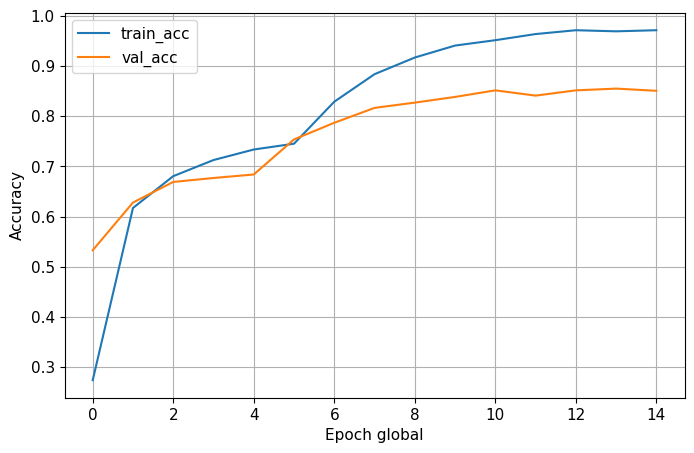

In [29]:
%matplotlib inline
plt.figure(figsize=(8, 5))
plt.plot(history_df["train_acc"], label="train_acc")
plt.plot(history_df["val_acc"], label="val_acc")
plt.xlabel("Epoch global")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 10. Mejor modelo

Esta celda permite validar que el checkpoint se puede cargar correctamente después del entrenamiento.

In [30]:
def load_trained_resnet50(checkpoint_path: Path, device: torch.device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = build_resnet50(num_classes=checkpoint["num_classes"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint

best_model, best_checkpoint = load_trained_resnet50(BEST_MODEL_PATH, DEVICE)
print("Modelo cargado correctamente.")
print("best_val_acc:", best_checkpoint["best_val_acc"])
print("idx_to_class_name:", best_checkpoint["idx_to_class_name"])

Modelo cargado correctamente.
best_val_acc: 0.8550218340611354
idx_to_class_name: {0: 'Hued hued', 1: 'Pudu', 2: 'Liebre europea', 3: 'Oveja', 4: 'Perro domestico', 5: 'Vaca', 6: 'Zorro culpeo', 7: 'Vison americano', 8: 'Quique', 9: 'Jabali', 10: 'Zorro chilla', 11: 'Conejo europeo', 12: 'Puma', 13: 'Gato domestico', 14: 'Guina', 15: 'Chucao', 16: 'Zorzal', 17: 'Caballo', 18: 'Chingue', 19: 'Guanaco', 20: 'Huemul'}


In [55]:
# Save best model path in google drive
DESTINATION_BEST_MODEL_PATH = "/content/drive/MyDrive/ECHO/Model/resnet50_species_best.pt"
best_model.load_state_dict(best_checkpoint["model_state_dict"])
torch.save(best_model.state_dict(), DESTINATION_BEST_MODEL_PATH)
print("Mejor modelo guardado en:", DESTINATION_BEST_MODEL_PATH)
# Save training history
DESTINATION_HISTORY_PATH = "/content/drive/MyDrive/ECHO/Model/training_history.csv"
history_df.to_csv(DESTINATION_HISTORY_PATH, index=False)
# Save resnet last weights
DESTINATION_LAST_MODEL_PATH = "/content/drive/MyDrive/ECHO/Model/resnet50_species_last.pt"
torch.save(best_checkpoint, DESTINATION_LAST_MODEL_PATH)
print("Historial guardado en:", DESTINATION_HISTORY_PATH)
print("Checkpoint guardado en:", DESTINATION_LAST_MODEL_PATH)
# Save class mapping json
DESTINATION_CLASS_MAPPING_PATH = "/content/drive/MyDrive/ECHO/Model/class_mapping.json"
with open(DESTINATION_CLASS_MAPPING_PATH, "w") as f:
    json.dump(best_checkpoint["class_id_to_name"], f, indent=4)
print("Mapeo de clases guardado en:", DESTINATION_CLASS_MAPPING_PATH)

Mejor modelo guardado en: /content/drive/MyDrive/ECHO/Model/resnet50_species_best.pt
Historial guardado en: /content/drive/MyDrive/ECHO/Model/training_history.csv
Checkpoint guardado en: /content/drive/MyDrive/ECHO/Model/resnet50_species_last.pt
Mapeo de clases guardado en: /content/drive/MyDrive/ECHO/Model/class_mapping.json


# Testing

## 1. Setup

In [31]:
!pip -q install scikit-learn openpyxl

import unicodedata
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [32]:
# Configuraciones generales
EVAL_IMAGES_ZIP = Path("/content/drive/MyDrive/ECHO/Metadata/downloaded_eval_images.zip")
EVAL_IMAGES_DIR = Path("/content/eval_downloaded_images")
EVAL_TEMPLATE_PATH = Path("/content/drive/MyDrive/ECHO/Metadata/Dataset_Evaluacion_EPII.xlsx")
EVAL_OUTPUT_PATH = Path("/content/drive/MyDrive/ECHO/Metadata/Plantilla_Evaluacion_Rellenada.xlsx")
EVAL_OUTPUT_CSV = Path("/content/drive/MyDrive/ECHO/Metadata/predicciones_evaluacion.csv")
SHEET_NAME = "Plantilla de Evaluación"
DET_CONF_THRESHOLD = 0.25
PADDING_RATIO = 0.10


In [33]:
EVAL_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

if EVAL_IMAGES_ZIP.exists():
    with zipfile.ZipFile(EVAL_IMAGES_ZIP, "r") as zf:
        zf.extractall(EVAL_IMAGES_DIR)
    print("ZIP extraído en:", EVAL_IMAGES_DIR)
else:
    print("No se encontró ZIP. Se usará carpeta:", EVAL_IMAGES_DIR)



ZIP extraído en: /content/eval_downloaded_images


## 2. Modelo Detector

In [34]:
DET_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

detector = pw_detection.MegaDetectorV6(
    device=DET_DEVICE,
    version="MDV6-yolov10-e"
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10x summary (fused): 191 layers, 29,399,417 parameters, 0 gradients, 160.0 GFLOPs


In [35]:
best_model.eval()
idx_to_class_name = {
    int(k): v for k, v in best_checkpoint["idx_to_class_name"].items()
}
print("Clases del modelo:", idx_to_class_name)
weights = ResNet50_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


Clases del modelo: {0: 'Hued hued', 1: 'Pudu', 2: 'Liebre europea', 3: 'Oveja', 4: 'Perro domestico', 5: 'Vaca', 6: 'Zorro culpeo', 7: 'Vison americano', 8: 'Quique', 9: 'Jabali', 10: 'Zorro chilla', 11: 'Conejo europeo', 12: 'Puma', 13: 'Gato domestico', 14: 'Guina', 15: 'Chucao', 16: 'Zorzal', 17: 'Caballo', 18: 'Chingue', 19: 'Guanaco', 20: 'Huemul'}


## 3. Utils del Detector y Clasificador

In [36]:
"""
Utils detector
"""
def clamp(value, min_value, max_value):
    return max(min_value, min(value, max_value))


def get_best_detection(detections, confidences):
    if len(detections) == 0 or len(confidences) == 0:
        return None, None

    best_idx = max(range(len(confidences)), key=lambda i: float(confidences[i]))
    best_bbox = detections[best_idx]
    best_conf = float(confidences[best_idx])

    return best_bbox, best_conf


def prepare_bbox(bbox, img_width, img_height, padding_ratio=0.10):
    x1, y1, x2, y2 = bbox

    if max(x1, y1, x2, y2) <= 1.0:
        x1 *= img_width
        x2 *= img_width
        y1 *= img_height
        y2 *= img_height

    x1, y1, x2, y2 = float(x1), float(y1), float(x2), float(y2)

    box_width = x2 - x1
    box_height = y2 - y1

    padding_x = box_width * padding_ratio
    padding_y = box_height * padding_ratio

    x1 = int(clamp(x1 - padding_x, 0, img_width))
    y1 = int(clamp(y1 - padding_y, 0, img_height))
    x2 = int(clamp(x2 + padding_x, 0, img_width))
    y2 = int(clamp(y2 + padding_y, 0, img_height))

    if x2 <= x1 or y2 <= y1:
        return None

    return x1, y1, x2, y2


def detect_and_crop(img_path):
    with torch.inference_mode():
        result = detector.single_image_detection(str(img_path))

    detections = result["detections"].xyxy
    confidences = result["detections"].confidence

    if hasattr(detections, "cpu"):
        detections = detections.cpu().numpy().tolist()

    if hasattr(confidences, "cpu"):
        confidences = confidences.cpu().numpy().tolist()

    best_bbox, best_conf = get_best_detection(detections, confidences)

    if best_bbox is None or best_conf is None:
        return None, best_conf, None

    if best_conf < DET_CONF_THRESHOLD:
        return None, best_conf, None

    with Image.open(img_path) as img:
        img = ImageOps.exif_transpose(img).convert("RGB")
        img_width, img_height = img.size

        bbox = prepare_bbox(
            best_bbox,
            img_width,
            img_height,
            padding_ratio=PADDING_RATIO,
        )

        if bbox is None:
            return None, best_conf, None

        crop = img.crop(bbox)
        crop = crop.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

    return crop, best_conf, bbox



In [37]:
"""
Utils classifier
"""
def normalize_text(text):
    text = "" if text is None else str(text)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    return text.lower().strip()


EVAL_SPECIES_MAP = {
    "guina": "Gato huiña",
    "gato huina": "Gato huiña",
    "gato huiña": "Gato huiña",
    "puma": "Puma",
    "zorzal": "Zorzal patagonico",
    "zorzal patagonico": "Zorzal patagonico",
    "chucao": "Chucao",
    "pudu": "Pudu",
    "hued hued": "Hued hued del sur",
    "hued hued del sur": "Hued hued del sur",
}


def to_eval_species(model_class_name):
    key = normalize_text(model_class_name)
    return EVAL_SPECIES_MAP.get(key, "Otro")


@torch.inference_mode()
def classify_crop(crop_img):
    x = eval_transform(crop_img).unsqueeze(0).to(DEVICE)

    logits = best_model(x)
    probs = torch.softmax(logits, dim=1)[0]

    pred_idx = int(torch.argmax(probs).item())
    pred_conf = float(probs[pred_idx].item())

    model_class_name = idx_to_class_name[pred_idx]
    eval_species = to_eval_species(model_class_name)

    return model_class_name, eval_species, pred_conf


def extract_excel_row_from_filename(img_path):
    # Ejemplo: row_0002__CAM6__1IZAOIR8S5BK.jpg -> 2
    match = re.search(r"row_(\d+)", img_path.stem)
    if not match:
        return None

    return int(match.group(1))



In [38]:
# Cargamos la plantilla para rellenarla
if not EVAL_TEMPLATE_PATH.exists():
    candidates = list(Path("/content/drive/MyDrive/ECHO/Protocolos/00_Evaluacion_SAVIIA_ML_Edge").glob("Dataset_Evaluacion_EPII*.xlsx"))
    candidates += list(Path("/content").glob("Dataset_Evaluacion_EPII*.xlsx"))

    if len(candidates) == 0:
        raise FileNotFoundError("No se encontró el Excel de evaluación.")

    EVAL_TEMPLATE_PATH = candidates[0]

print("Usando plantilla:", EVAL_TEMPLATE_PATH)

wb = openpyxl.load_workbook(EVAL_TEMPLATE_PATH)
ws = wb[SHEET_NAME]

headers = {
    ws.cell(row=1, column=col).value: col
    for col in range(1, ws.max_column + 1)
}

detect_col = headers["¿Detectas un animal claro?"]
species_col = headers["Especie (Clasificación)"]


Usando plantilla: /content/drive/MyDrive/ECHO/Protocolos/00_Evaluacion_SAVIIA_ML_Edge/Dataset_Evaluacion_EPII.xlsx


In [39]:
valid_exts = {".jpg", ".jpeg", ".png", ".webp"}

image_paths = sorted([
    p for p in EVAL_IMAGES_DIR.rglob("*")
    if p.suffix.lower() in valid_exts
])

print("Imágenes encontradas:", len(image_paths))

results = []

for img_path in tqdm(image_paths, desc="Evaluando imágenes"):
    excel_row = extract_excel_row_from_filename(img_path)

    if excel_row is None:
        continue
    # 1. preprocesamiento de la imagen - deteccion y recorte
    crop_img, det_conf, bbox = detect_and_crop(img_path)

    if crop_img is None:
        animal_clear = "No"
        eval_species = "Otro"
        model_class_name = None
        cls_conf = None

    else:
        # 2. clasificacion de la imagen
        animal_clear = "Si"
        model_class_name, eval_species, cls_conf = classify_crop(crop_img)

    ws.cell(row=excel_row, column=detect_col).value = animal_clear
    ws.cell(row=excel_row, column=species_col).value = eval_species

    results.append({
        "excel_row": excel_row,
        "image_path": str(img_path),
        "detecta_animal_claro": animal_clear,
        "especie_evaluacion": eval_species,
        "clase_modelo_original": model_class_name,
        "det_conf": det_conf,
        "cls_conf": cls_conf,
        "bbox": bbox,
    })

Imágenes encontradas: 77


Evaluando imágenes:   0%|          | 0/77 [00:00<?, ?it/s]


0: 1280x1280 1 animal, 255.1ms
Speed: 18.2ms preprocess, 255.1ms inference, 0.8ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 261.0ms
Speed: 14.0ms preprocess, 261.0ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 2 animals, 252.8ms
Speed: 11.6ms preprocess, 252.8ms inference, 0.8ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 252.9ms
Speed: 10.6ms preprocess, 252.9ms inference, 0.5ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 248.5ms
Speed: 5.6ms preprocess, 248.5ms inference, 0.5ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 250.7ms
Speed: 6.2ms preprocess, 250.7ms inference, 0.7ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 253.3ms
Speed: 18.2ms preprocess, 253.3ms inference, 0.7ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 1 animal, 250.5ms
Speed: 8.3ms preprocess, 250.5ms infer

In [40]:
wb.save(EVAL_OUTPUT_PATH)
results_df = pd.DataFrame(results).sort_values("excel_row")
results_df.to_csv(EVAL_OUTPUT_CSV, index=False)
print("Excel rellenado:", EVAL_OUTPUT_PATH)
print("CSV predicciones:", EVAL_OUTPUT_CSV)
display(results_df.head(20))
print(results_df["detecta_animal_claro"].value_counts(dropna=False))
print(results_df["especie_evaluacion"].value_counts(dropna=False))

Excel rellenado: /content/drive/MyDrive/ECHO/Metadata/Plantilla_Evaluacion_Rellenada.xlsx
CSV predicciones: /content/drive/MyDrive/ECHO/Metadata/predicciones_evaluacion.csv


,excel_row,image_path,detecta_animal_claro,especie_evaluacion,clase_modelo_original,det_conf,cls_conf,bbox
0,2,/content/eval_downloaded_images/row_0002__CAM6...,Si,Puma,Puma,0.883339,0.185884,"(1747, 1672, 3046, 2404)"
1,3,/content/eval_downloaded_images/row_0003__CAM1...,Si,Zorzal patagonico,Zorzal,0.854140,0.362164,"(675, 1140, 903, 1448)"
2,4,/content/eval_downloaded_images/row_0004__CAM6...,Si,Otro,Liebre europea,0.752975,0.279980,"(2409, 1486, 3264, 2423)"
3,5,/content/eval_downloaded_images/row_0005__CAM2...,Si,Puma,Puma,0.951253,0.522642,"(118, 917, 1622, 1433)"
4,6,/content/eval_downloaded_images/row_0006__CAM4...,Si,Hued hued del sur,Hued hued,0.897499,0.380973,"(698, 451, 847, 666)"
5,7,/content/eval_downloaded_images/row_0007__CAM4...,Si,Zorzal patagonico,Zorzal,0.803550,0.787541,"(804, 506, 1028, 682)"
6,8,/content/eval_downloaded_images/row_0008__CAM5...,Si,Otro,Vison americano,0.929259,0.362928,"(398, 893, 754, 1144)"
7,9,/content/eval_downloaded_images/row_0009__CAM4...,Si,Zorzal patagonico,Zorzal,0.897501,0.260781,"(621, 495, 838, 685)"
8,10,/content/eval_downloaded_images/row_0010__CAM1...,Si,Otro,Chingue,0.887220,0.208916,"(2777, 1494, 3122, 1794)"
9,11,/content/eval_downloaded_images/row_0011__CAM1...,Si,Hued hued del sur,Hued hued,0.479239,0.322438,"(1738, 1754, 1988, 1978)"


detecta_animal_claro
Si    76
No     1
Name: count, dtype: int64
especie_evaluacion
Pudu                 18
Zorzal patagonico    17
Otro                 15
Hued hued del sur    11
Puma                  7
Chucao                5
Gato huiña            4
Name: count, dtype: int64


## 4. Metricas de evaluacion del clasificador

In [41]:
# cargamos el excel de verdad absoluta.
GT_EXCEL_PATH = EVAL_TEMPLATE_PATH
GT_SHEET_NAME = "Ground Truth Dataset"
if "results_df" not in globals():
    results_df = pd.read_csv(EVAL_OUTPUT_CSV)


In [42]:
"""
Utils
"""
def norm_text(x):
    if pd.isna(x):
        return ""

    x = str(x).strip()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    x = x.lower().strip()
    return x

def canonical_species(x):
    key = norm_text(x)
    if key == "":
        return None
    return SPECIES_CANONICAL_MAP.get(key, "Unknown")


def is_detected(x):
    key = norm_text(x)
    return key in {"si", "sí", "yes", "true", "1"}



In [43]:
# mapeo de especies (compatibilidad con el excel)
SPECIES_CANONICAL_MAP = {
    "chucao": "Chucao",

    "gato huina": "Gato huiña",
    "gato huiña": "Gato huiña",
    "guina": "Gato huiña",

    "hued hued": "Hued hued del sur",
    "hued hued del sur": "Hued hued del sur",

    "pudu": "Pudú",
    "pudú": "Pudú",

    "puma": "Puma",

    "zorzal": "Zorzal patagónico",
    "zorzal patagonico": "Zorzal patagónico",
    "zorzal patagónico": "Zorzal patagónico",

    "unknown": "Unknown",
    "otro": "Unknown",
}

In [44]:
gt_df = pd.read_excel(GT_EXCEL_PATH, sheet_name=GT_SHEET_NAME)
gt_df["excel_row"] = gt_df.index + 2
gt_df["gt_label"] = gt_df["Common Name"].apply(canonical_species)


In [45]:
def build_combined_pred(row):
    if not row["pred_detected"]:
        return "No detectado"

    if row["pred_species"] is None:
        return "Sin respuesta"

    return row["pred_species"]

pred_df = results_df.copy()
pred_df["pred_detected"] = pred_df["detecta_animal_claro"].apply(is_detected)
pred_df["pred_species"] = pred_df["especie_evaluacion"].apply(canonical_species)
pred_df["pred_combined_label"] = pred_df.apply(build_combined_pred, axis=1)


In [46]:
eval_df = gt_df.merge(
    pred_df,
    on="excel_row",
    how="inner",
)
eval_df["gt_combined_label"] = eval_df["gt_label"]
print("Filas evaluadas:", len(eval_df))


Filas evaluadas: 77


### Resultados generales

In [47]:
# Cargamos los labels gold truth y predicciones
y_true = eval_df["gt_combined_label"]
y_pred = eval_df["pred_combined_label"]

# Accuracy general usando etiqueta combinada
overall_accuracy = accuracy_score(y_true, y_pred)
#  Detección
detection_score = eval_df["pred_detected"].mean()
#  Accuracy clasificación pura
cls_eval_df = eval_df[
    (eval_df["pred_detected"] == True) &
    (eval_df["pred_species"].notna())
].copy()
if len(cls_eval_df) > 0:
    pure_classification_accuracy = accuracy_score(
        cls_eval_df["gt_label"],
        cls_eval_df["pred_species"],
    )
else:
    pure_classification_accuracy = np.nan
# F1 scores usando etiqueta combinada
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

# Cohen kappa vs GT
# TODO: pendiente

metrics = {
    "n": len(eval_df),
    "Accuracy": overall_accuracy,
    "Deteccion": detection_score,
    "Acc_clasificacion_pura": pure_classification_accuracy,
    "F1_macro": f1_macro,
    "F1_micro": f1_micro,
    "F1_weighted": f1_weighted,
}

metrics_df = pd.DataFrame([metrics])
# Metricas generales del modelo
display(metrics_df)

,n,Accuracy,Deteccion,Acc_clasificacion_pura,F1_macro,F1_micro,F1_weighted
0,77,0.454545,0.987013,0.460526,0.381889,0.454545,0.436445


### Resultados por clase

In [48]:
# Reporte de evaluacion por clase
report_dict = classification_report(
    y_true,
    y_pred,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

,precision,recall,f1-score,support
Chucao,0.600000,0.272727,0.375000,11.000000
Gato huiña,0.500000,0.181818,0.266667,11.000000
Hued hued del sur,0.545455,0.545455,0.545455,11.000000
No detectado,0.000000,0.000000,0.000000,0.000000
Pudú,0.500000,0.818182,0.620690,11.000000
Puma,0.571429,0.363636,0.444444,11.000000
Unknown,0.142857,0.181818,0.160000,11.000000
Zorzal patagónico,0.529412,0.818182,0.642857,11.000000
accuracy,0.454545,0.454545,0.454545,0.454545
macro avg,0.423644,0.397727,0.381889,77.000000


### Matriz de confusion


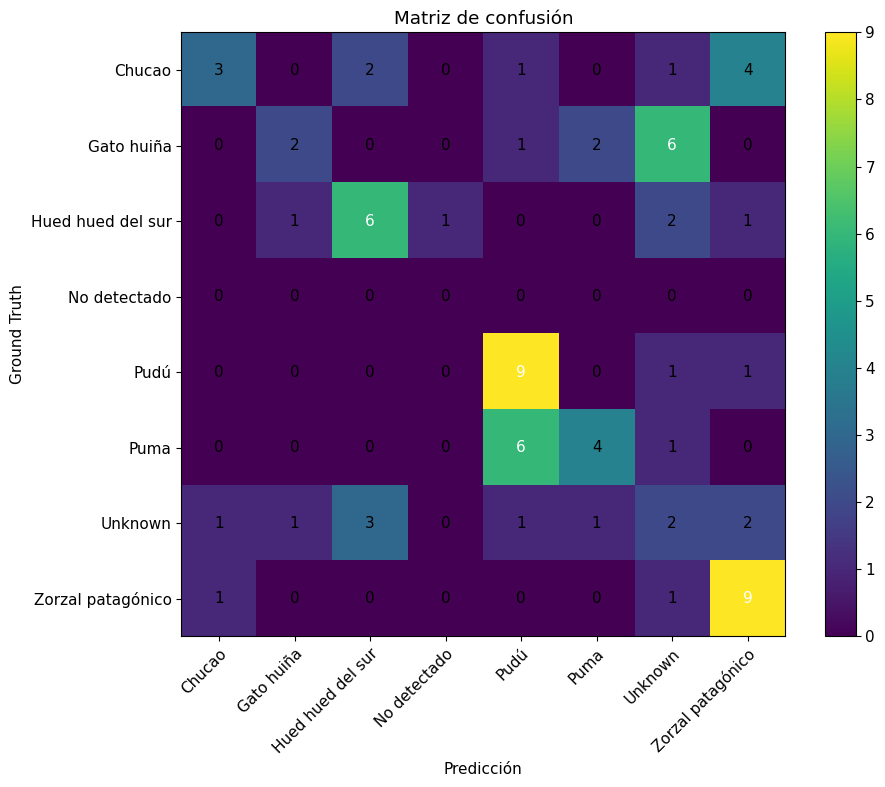

In [49]:
# Matriz de confusion

labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest")
# im = ax.imshow(cm_norm, interpolation="nearest")
# ax.text(
#     j, i, f"{cm_norm[i, j]:.2f}",
#     ha="center", va="center",
#     color="white" if cm_norm[i, j] > 0.5 else "black"
# )
plt.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(labels)),
    yticks=np.arange(len(labels)),
    xticklabels=labels,
    yticklabels=labels,
    xlabel="Predicción",
    ylabel="Ground Truth",
    title="Matriz de confusión"
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()

In [58]:
# Archivos finales del resultado de deteccion y clasificacion...
METRICS_OUTPUT_PATH = "/content/drive/MyDrive/ECHO/Model_Evaluation/metricas_modelo_eval.csv"
REPORT_OUTPUT_PATH = "/content/drive/MyDrive/ECHO/Model_Evaluation/reporte_clases_modelo_eval.csv"
CONFUSION_OUTPUT_PATH = "/content/drive/MyDrive/ECHO/Model_Evaluation/matriz_confusion_modelo_eval.csv"
EVAL_ROWS_OUTPUT_PATH = "/content/drive/MyDrive/ECHO/Model_Evaluation/eval_rows_modelo.csv"

metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
report_df.to_csv(REPORT_OUTPUT_PATH)
# cm_df.to_csv(CONFUSION_OUTPUT_PATH)
eval_df.to_csv(EVAL_ROWS_OUTPUT_PATH, index=False)

print("Métricas guardadas en:", METRICS_OUTPUT_PATH)
print("Reporte por clase guardado en:", REPORT_OUTPUT_PATH)
# print("Matriz de confusión guardada en:", CONFUSION_OUTPUT_PATH)
print("Filas evaluadas guardadas en:", EVAL_ROWS_OUTPUT_PATH)

Métricas guardadas en: /content/drive/MyDrive/ECHO/Model_Evaluation/metricas_modelo_eval.csv
Reporte por clase guardado en: /content/drive/MyDrive/ECHO/Model_Evaluation/reporte_clases_modelo_eval.csv
Filas evaluadas guardadas en: /content/drive/MyDrive/ECHO/Model_Evaluation/eval_rows_modelo.csv
